# C. Late Delivery Risk Model & Business Recommendation

**Key constraint:** We can only use features known at order time, not delivery dates.

---

In [2]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (classification_report, roc_auc_score,
                             precision_recall_curve, roc_curve,
                             confusion_matrix, ConfusionMatrixDisplay)

sns.set_theme(style='whitegrid', palette='muted')
conn = sqlite3.connect('../data/olist.db')
print('Connected.')

Connected.


## 1. Feature Engineering

I build features that would be available to the platform at order placement time.

In [5]:
df = pd.read_sql("""
    SELECT
        o.order_id,
        o.order_purchase_timestamp,
        o.order_estimated_delivery_date,
        o.order_delivered_customer_date,

        -- TARGET
        CASE
            WHEN o.order_delivered_customer_date > o.order_estimated_delivery_date
            THEN 1 ELSE 0
        END AS is_late,

        -- FEATURES KNOWN AT ORDER TIME

        -- Promised delivery window
        ROUND(JULIANDAY(o.order_estimated_delivery_date)
            - JULIANDAY(o.order_purchase_timestamp)) AS promised_days,

        -- Order characteristics
        oi.n_items,
        oi.total_price,
        oi.total_freight,
        oi.n_sellers,
        oi.avg_product_weight_g,
        oi.avg_product_volume_cm3,

        -- Category of primary item
        oi.primary_category,

        -- Seller location
        oi.seller_state,

        -- Customer location
        c.customer_state,

        -- Same state flag
        CASE WHEN oi.seller_state = c.customer_state THEN 1 ELSE 0 END AS same_state,

        -- Seller historical performance
        seller_hist.seller_order_count,
        seller_hist.seller_late_rate,
        seller_hist.seller_avg_ship_days,

        -- Time features
        CAST(strftime('%w', o.order_purchase_timestamp) AS INTEGER) AS day_of_week,
        CAST(strftime('%m', o.order_purchase_timestamp) AS INTEGER) AS month

    FROM orders o

    -- Order-level item aggregates
    LEFT JOIN (
        SELECT
            sub.order_id,
            COUNT(*) AS n_items,
            ROUND(SUM(sub.price), 2) AS total_price,
            ROUND(SUM(sub.freight_value), 2) AS total_freight,
            COUNT(DISTINCT sub.seller_id) AS n_sellers,
            AVG(sub.product_weight_g) AS avg_product_weight_g,
            AVG(sub.product_length_cm * sub.product_height_cm * sub.product_width_cm)
                AS avg_product_volume_cm3,
            MAX(CASE WHEN sub.rn = 1 THEN sub.category END) AS primary_category,
            MAX(CASE WHEN sub.rn = 1 THEN sub.seller_id END) AS primary_seller_id,
            MAX(CASE WHEN sub.rn = 1 THEN sub.seller_state END) AS seller_state
        FROM (
            SELECT
                oi_inner.order_id,
                oi_inner.seller_id,
                oi_inner.price,
                oi_inner.freight_value,
                p.product_weight_g,
                p.product_length_cm,
                p.product_height_cm,
                p.product_width_cm,
                COALESCE(ct.product_category_name_english, p.product_category_name)
                    AS category,
                s.seller_state,
                ROW_NUMBER() OVER (PARTITION BY oi_inner.order_id
                                   ORDER BY oi_inner.price DESC) AS rn
            FROM order_items oi_inner
            LEFT JOIN products p ON oi_inner.product_id = p.product_id
            LEFT JOIN category_translation ct
                ON p.product_category_name = ct.product_category_name
            LEFT JOIN sellers s ON oi_inner.seller_id = s.seller_id
        ) sub
        GROUP BY sub.order_id
    ) oi ON o.order_id = oi.order_id

    LEFT JOIN customers c ON o.customer_id = c.customer_id

    -- Seller historical stats
    LEFT JOIN (
        SELECT
            oi3.seller_id,
            COUNT(DISTINCT oi3.order_id) AS seller_order_count,
            ROUND(AVG(CASE
                WHEN o2.order_delivered_customer_date > o2.order_estimated_delivery_date
                THEN 1.0 ELSE 0.0 END), 3) AS seller_late_rate,
            ROUND(AVG(
                JULIANDAY(o2.order_delivered_carrier_date)
                - JULIANDAY(o2.order_approved_at)
            ), 1) AS seller_avg_ship_days
        FROM order_items oi3
        JOIN orders o2 ON oi3.order_id = o2.order_id
        WHERE o2.order_status = 'delivered'
        GROUP BY oi3.seller_id
    ) seller_hist ON seller_hist.seller_id = oi.primary_seller_id

    WHERE o.order_status = 'delivered'
      AND o.order_delivered_customer_date IS NOT NULL
      AND o.order_estimated_delivery_date IS NOT NULL
""", conn)

print(f'Rows: {len(df):,}')
print(f'Late rate: {df["is_late"].mean():.1%}')
df.head(3)

Rows: 96,470
Late rate: 8.1%


,order_id,order_purchase_timestamp,order_estimated_delivery_date,order_delivered_customer_date,is_late,promised_days,n_items,total_price,total_freight,n_sellers,...,avg_product_volume_cm3,primary_category,seller_state,customer_state,same_state,seller_order_count,seller_late_rate,seller_avg_ship_days,day_of_week,month
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,2017-10-18 00:00:00,2017-10-10 21:25:13,0,16.0,1,29.99,8.72,1,...,1976.0,housewares,SP,SP,1,53,0.000,1.6,1,10
1,53cdb2fc8bc7dce0b6741e2150273451,2018-07-24 20:41:37,2018-08-13 00:00:00,2018-08-07 15:27:45,0,19.0,1,118.70,22.76,1,...,4693.0,perfumery,SP,BA,0,109,0.016,1.2,2,7
2,47770eb9100c2d0c44946d9cf07ec65d,2018-08-08 08:38:49,2018-09-04 00:00:00,2018-08-17 18:06:29,0,27.0,1,159.90,19.22,1,...,9576.0,auto,SP,GO,0,1124,0.116,2.3,3,8


In [6]:
# Define feature columns
numeric_features = [
    'promised_days',
    'n_items',
    'total_price',
    'total_freight',
    'n_sellers',
    'avg_product_weight_g',
    'avg_product_volume_cm3',
    'same_state',
    'seller_order_count',
    'seller_late_rate',
    'seller_avg_ship_days',
    'day_of_week',
    'month',
]

categorical_features = ['seller_state', 'customer_state']

target = 'is_late'

# Handle missing values
print('Missing values in numeric features:')
print(df[numeric_features].isnull().sum()[df[numeric_features].isnull().sum() > 0])
print()

# Fill numeric nulls with median
for col in numeric_features:
    df[col] = df[col].fillna(df[col].median())

# Encode categorical features
label_encoders = {}
for col in categorical_features:
    df[col] = df[col].fillna('UNKNOWN')
    le = LabelEncoder()
    df[col + '_enc'] = le.fit_transform(df[col])
    label_encoders[col] = le

feature_cols = numeric_features + [c + '_enc' for c in categorical_features]
print(f'Total features: {len(feature_cols)}')

Missing values in numeric features:
avg_product_weight_g      16
avg_product_volume_cm3    16
dtype: int64

Total features: 15


## 2. Train / Test Split

I use a **time-based split** i.e. train on earlier orders, test on later ones.

In [7]:
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

# Split: train on orders before 2018-04, test on 2018-04 onwards
split_date = '2018-04-01'
train = df[df['order_purchase_timestamp'] < split_date].copy()
test = df[df['order_purchase_timestamp'] >= split_date].copy()

X_train = train[feature_cols]
y_train = train[target]
X_test = test[feature_cols]
y_test = test[target]

print(f'Train: {len(train):,} orders ({train["order_purchase_timestamp"].min().date()} to {train["order_purchase_timestamp"].max().date()})')
print(f'Test:  {len(test):,} orders ({test["order_purchase_timestamp"].min().date()} to {test["order_purchase_timestamp"].max().date()})')
print(f'Train late rate: {y_train.mean():.1%}')
print(f'Test late rate:  {y_test.mean():.1%}')

Train: 64,320 orders (2016-09-15 to 2018-03-31)
Test:  32,150 orders (2018-04-01 to 2018-08-29)
Train late rate: 9.2%
Test late rate:  6.0%


## 3. Model Training

In [8]:
# Model A: Logistic Regression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr.fit(X_train_scaled, y_train)

lr_probs = lr.predict_proba(X_test_scaled)[:, 1]
lr_auc = roc_auc_score(y_test, lr_probs)
print(f'Logistic Regression AUC: {lr_auc:.3f}')

Logistic Regression AUC: 0.760


In [9]:
# Model B: Gradient Boosting
gb = GradientBoostingClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    random_state=42
)
gb.fit(X_train, y_train)

gb_probs = gb.predict_proba(X_test)[:, 1]
gb_auc = roc_auc_score(y_test, gb_probs)
print(f'Gradient Boosting AUC:   {gb_auc:.3f}')
print()

# Pick the better model
if gb_auc >= lr_auc:
    best_name = 'Gradient Boosting'
    best_probs = gb_probs
    best_model = gb
else:
    best_name = 'Logistic Regression'
    best_probs = lr_probs
    best_model = lr

print(f'Selected model: {best_name} (AUC={max(gb_auc, lr_auc):.3f})')

Gradient Boosting AUC:   0.813

Selected model: Gradient Boosting (AUC=0.813)


## 4. Model Evaluation

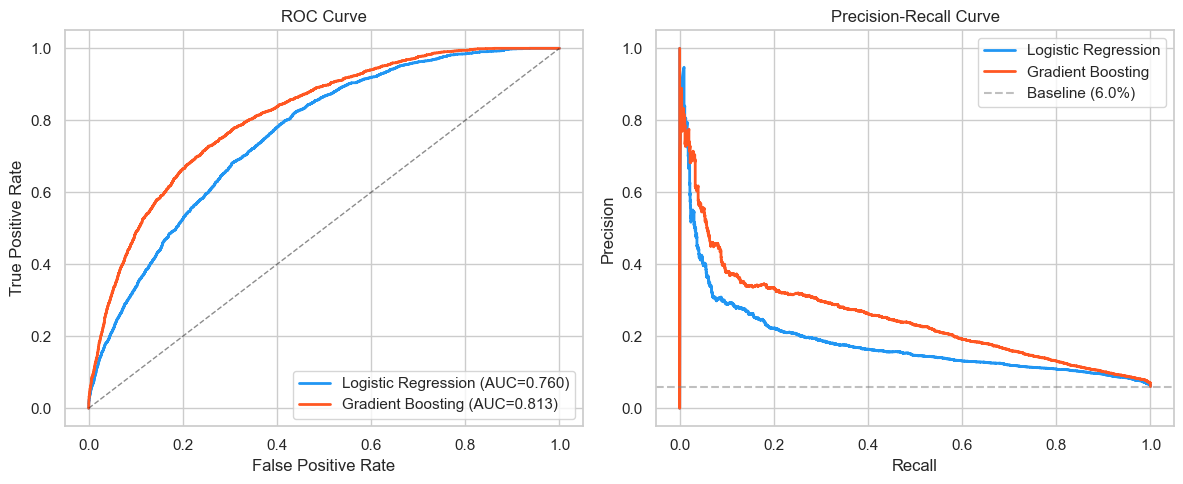

In [10]:
# ROC curve comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

for name, probs, color in [('Logistic Regression', lr_probs, '#2196F3'),
                            ('Gradient Boosting', gb_probs, '#FF5722')]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    ax1.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={auc:.3f})')

ax1.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curve')
ax1.legend(loc='lower right')

# Precision-Recall curve
for name, probs, color in [('Logistic Regression', lr_probs, '#2196F3'),
                            ('Gradient Boosting', gb_probs, '#FF5722')]:
    precision, recall, _ = precision_recall_curve(y_test, probs)
    ax2.plot(recall, precision, color=color, lw=2, label=name)

ax2.axhline(y=y_test.mean(), color='gray', linestyle='--', alpha=0.5, label=f'Baseline ({y_test.mean():.1%})')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curve')
ax2.legend()

plt.tight_layout()
plt.savefig('../output/03_roc_pr_curves.png', dpi=150)
plt.show()

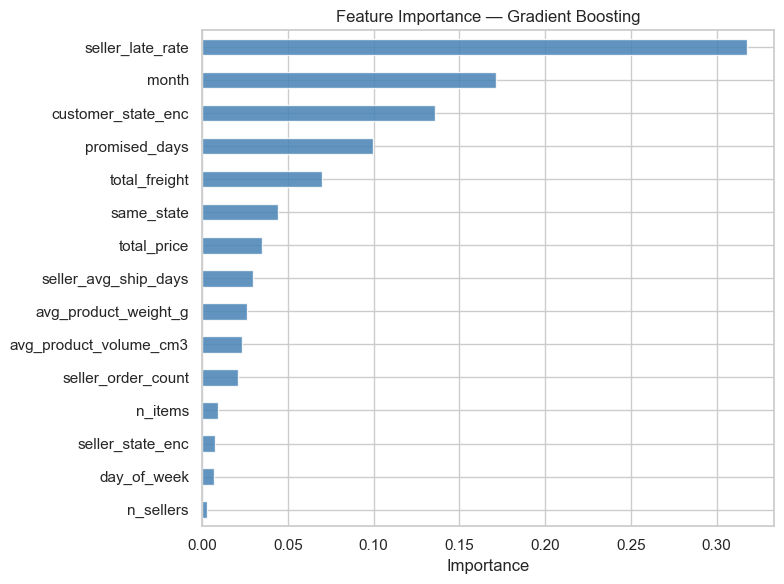

Top 5 features:
  total_freight                   0.070
  promised_days                   0.100
  customer_state_enc              0.136
  month                           0.171
  seller_late_rate                0.318


In [11]:
# Feature importance (Gradient Boosting)
importances = pd.Series(gb.feature_importances_, index=feature_cols)
importances = importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
importances.plot.barh(ax=ax, color='steelblue', alpha=0.85)
ax.set_title('Feature Importance — Gradient Boosting')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig('../output/03_feature_importance.png', dpi=150)
plt.show()

print('Top 5 features:')
for feat, imp in importances.tail(5).items():
    print(f'  {feat:<30s}  {imp:.3f}')

## 5. Setting the Decision Threshold


In [12]:
# Evaluate at different thresholds
thresholds = [0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50]

results = []
for t in thresholds:
    preds = (best_probs >= t).astype(int)
    flagged = preds.sum()
    flagged_pct = preds.mean()
    true_late_caught = ((preds == 1) & (y_test == 1)).sum()
    total_late = y_test.sum()
    recall = true_late_caught / total_late if total_late > 0 else 0
    precision = true_late_caught / flagged if flagged > 0 else 0
    results.append({
        'threshold': t,
        'orders_flagged': flagged,
        'pct_flagged': f'{flagged_pct:.1%}',
        'late_caught': true_late_caught,
        'total_late': int(total_late),
        'recall': f'{recall:.1%}',
        'precision': f'{precision:.1%}'
    })

threshold_df = pd.DataFrame(results)
print('Threshold Analysis (test set):')
print()
print(threshold_df.to_string(index=False))
print()
print('Read this as: at threshold 0.20, we flag X% of orders and catch Y% of actual late deliveries.')
print('The right threshold depends on the cost of intervention vs. cost of a late delivery.')

Threshold Analysis (test set):

 threshold  orders_flagged pct_flagged  late_caught  total_late recall precision
      0.10            6872       21.4%         1244        1936  64.3%     18.1%
      0.15            4049       12.6%          954        1936  49.3%     23.6%
      0.20            2621        8.2%          717        1936  37.0%     27.4%
      0.25            1750        5.4%          541        1936  27.9%     30.9%
      0.30            1185        3.7%          393        1936  20.3%     33.2%
      0.40             613        1.9%          226        1936  11.7%     36.9%
      0.50             317        1.0%          144        1936   7.4%     45.4%

Read this as: at threshold 0.20, we flag X% of orders and catch Y% of actual late deliveries.
The right threshold depends on the cost of intervention vs. cost of a late delivery.


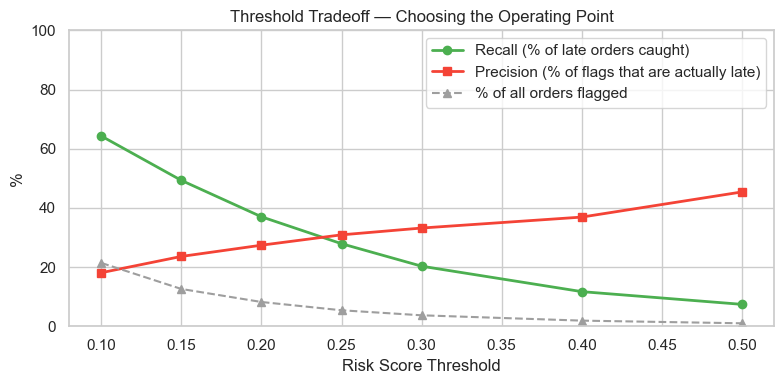

In [13]:
# Visualize threshold tradeoff
res_df = pd.DataFrame(results)
res_df['recall_num'] = res_df['recall'].str.rstrip('%').astype(float)
res_df['precision_num'] = res_df['precision'].str.rstrip('%').astype(float)
res_df['flagged_num'] = res_df['pct_flagged'].str.rstrip('%').astype(float)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(res_df['threshold'], res_df['recall_num'], 'o-', color='#4CAF50', lw=2, label='Recall (% of late orders caught)')
ax.plot(res_df['threshold'], res_df['precision_num'], 's-', color='#F44336', lw=2, label='Precision (% of flags that are actually late)')
ax.plot(res_df['threshold'], res_df['flagged_num'], '^--', color='#9E9E9E', lw=1.5, label='% of all orders flagged')

ax.set_xlabel('Risk Score Threshold')
ax.set_ylabel('%')
ax.set_title('Threshold Tradeoff — Choosing the Operating Point')
ax.legend()
ax.set_ylim(0, 100)
plt.tight_layout()
plt.savefig('../output/03_threshold_tradeoff.png', dpi=150)
plt.show()

## 6. Confusion Matrix at Recommended Threshold

A threshold of 0.20 was selected because it provides a practical balance between recall and precision. At this threshold, the model identifies 37% of all late deliveries while requiring intervention on only 8.2% of orders. Lower thresholds capture more late deliveries but generate substantially more false positives, whereas higher thresholds reduce operational workload but miss a large proportion of late deliveries.

---

Results at threshold 0.2

              precision    recall  f1-score   support

     On time       0.96      0.94      0.95     30214
        Late       0.27      0.37      0.31      1936

    accuracy                           0.90     32150
   macro avg       0.62      0.65      0.63     32150
weighted avg       0.92      0.90      0.91     32150



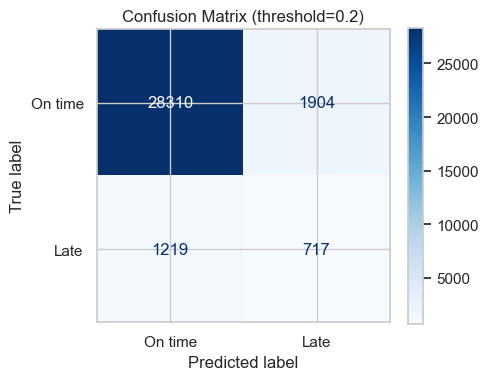

In [14]:
# Pick a practical threshold
THRESHOLD = 0.20

final_preds = (best_probs >= THRESHOLD).astype(int)

print(f'Results at threshold {THRESHOLD}')
print()
print(classification_report(y_test, final_preds, target_names=['On time', 'Late']))

fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_test, final_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=['On time', 'Late'])
disp.plot(ax=ax, cmap='Blues')
ax.set_title(f'Confusion Matrix (threshold={THRESHOLD})')
plt.tight_layout()
plt.savefig('../output/03_confusion_matrix.png', dpi=150)
plt.show()

## 7. Business Recommendation

This section translates model output into a concrete intervention proposal.

In [16]:
# Simulate the intervention impact
test_with_scores = test.copy()
test_with_scores['risk_score'] = best_probs
test_with_scores['flagged'] = (best_probs >= THRESHOLD).astype(int)

flagged_orders = test_with_scores[test_with_scores['flagged'] == 1]
flagged_late = flagged_orders[flagged_orders['is_late'] == 1]

total_test_orders = len(test_with_scores)
total_test_late = test_with_scores['is_late'].sum()

print('BUSINESS RECOMMENDATION')
print()
print(f'At threshold {THRESHOLD}:')
print(f'  Orders flagged as high-risk:  {len(flagged_orders):,} ({len(flagged_orders)/total_test_orders:.1%} of all orders)')
print(f'  Actual late orders caught:    {len(flagged_late):,} ({len(flagged_late)/total_test_late:.1%} of all late orders)')
print()
print('PROPOSED INTERVENTIONS FOR FLAGGED ORDERS:')
print()
print('  1. ADJUST DELIVERY ESTIMATE: Add 3-5 day buffer to promised date.')
print('     Cost: Zero. Effect: Turns "late" deliveries into "on-time" deliveries by managing expectations upfront')
print()
print('  2. PROACTIVE CUSTOMER NOTIFICATION: Send a message at day 7 if the order hasn\'t reached the carrier yet.')
print('     Cost: Minimal (automated). Effect: Reduces surprise and 1-star reviews.')
print()
print('  3. SELLER ACCOUNTABILITY: Flag D-tier sellers in internal dashboards.')
print('     Require improvement plan or reduce order routing.')
print('     Cost: Ops team time. Effect: Addresses root cause.')
print()

BUSINESS RECOMMENDATION

At threshold 0.2:
  Orders flagged as high-risk:  2,621 (8.2% of all orders)
  Actual late orders caught:    717 (37.0% of all late orders)

PROPOSED INTERVENTIONS FOR FLAGGED ORDERS:

  1. ADJUST DELIVERY ESTIMATE: Add 3-5 day buffer to promised date.
     Cost: Zero. Effect: Turns "late" deliveries into "on-time" deliveries by managing expectations upfront

  2. PROACTIVE CUSTOMER NOTIFICATION: Send a message at day 7 if the order hasn't reached the carrier yet.
     Cost: Minimal (automated). Effect: Reduces surprise and 1-star reviews.

  3. SELLER ACCOUNTABILITY: Flag D-tier sellers in internal dashboards.
     Require improvement plan or reduce order routing.
     Cost: Ops team time. Effect: Addresses root cause.



In [18]:
# Estimate impact of Intervention 1: adjusting delivery window
# If we add 5 days to the estimate for flagged orders, how many "late" become "on time"?

test_with_scores['adjusted_estimate'] = pd.to_datetime(test_with_scores['order_estimated_delivery_date'])
test_with_scores['actual_delivery'] = pd.to_datetime(test_with_scores['order_delivered_customer_date'])

# Add 5 days to flagged orders' estimates
buffer_days = 5
test_with_scores['new_estimate'] = test_with_scores['adjusted_estimate']
mask = test_with_scores['flagged'] == 1
test_with_scores.loc[mask, 'new_estimate'] = (
    test_with_scores.loc[mask, 'adjusted_estimate'] + pd.Timedelta(days=buffer_days)
)

# Recalculate late flag with adjusted estimate
test_with_scores['would_be_late'] = (
    test_with_scores['actual_delivery'] > test_with_scores['new_estimate']
).astype(int)

original_late_rate = test_with_scores['is_late'].mean()
new_late_rate = test_with_scores['would_be_late'].mean()
reduction = original_late_rate - new_late_rate

print(f'IMPACT OF +{buffer_days} DAY BUFFER ON FLAGGED ORDERS')
print(f'  Original late rate:  {original_late_rate:.1%}')
print(f'  New late rate:       {new_late_rate:.1%}')
print(f'  Reduction:           {reduction:.1%} ({reduction/original_late_rate:.0%} relative improvement)')
print()
late_prevented = test_with_scores['is_late'].sum() - test_with_scores['would_be_late'].sum()
print(f'  Late deliveries prevented: {late_prevented:,}')
print(f'  1-star reviews prevented (est.): ~{int(late_prevented * 0.46):,}')
print(f'    (based on 46% of late orders receiving 1-star)')

IMPACT OF +5 DAY BUFFER ON FLAGGED ORDERS
  Original late rate:  6.0%
  New late rate:       4.5%
  Reduction:           1.5% (25% relative improvement)

  Late deliveries prevented: 478
  1-star reviews prevented (est.): ~219
    (based on 46% of late orders receiving 1-star)


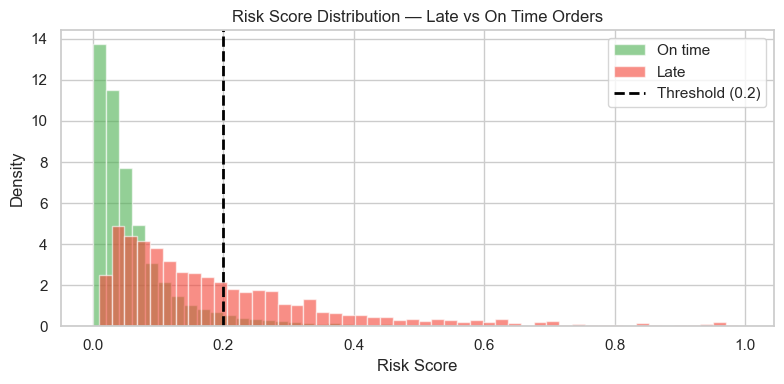

In [19]:
# Final summary visualization: risk score distribution by outcome
fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(test_with_scores[test_with_scores['is_late']==0]['risk_score'],
        bins=50, alpha=0.6, color='#4CAF50', label='On time', density=True)
ax.hist(test_with_scores[test_with_scores['is_late']==1]['risk_score'],
        bins=50, alpha=0.6, color='#F44336', label='Late', density=True)
ax.axvline(x=THRESHOLD, color='black', linestyle='--', lw=2,
           label=f'Threshold ({THRESHOLD})')

ax.set_xlabel('Risk Score')
ax.set_ylabel('Density')
ax.set_title('Risk Score Distribution — Late vs On Time Orders')
ax.legend()
plt.tight_layout()
plt.savefig('../output/03_risk_distribution.png', dpi=150)
plt.show()

In [22]:
conn.close()

print('Project Completed')

Project Completed
